# Импорт библиотек и классов

In [27]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np
import torch.utils.data as data
from tqdm import tqdm

In [28]:
from gpt_pre_norm import GPTPreNorm
from gpt_post_norm import GPTPostNorm
from gpt_pre_norm_with_RoPe import GPTPreNormWithRoPe
from gpt_pre_norm_with_RoPe_with_MoE import GPTPreNormWithRoPeWithMoE
from dataset_and_tokenizer import BookDataset, MyTokenizerMaker

In [29]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# Запуски

Где будет запускаться ноутбук: личный пк или google colab

In [30]:
# place_of_work = "colab"
place_of_work = "pc"

In [31]:
models = ["gpt_pre-norm", "gpt_post-norm", "gpt_pre-norm_with_RoPe", "gpt_pre-norm_with_RoPe_with_MoE"]

In [32]:
save_dir = "."

if place_of_work == "colab":
    if os.path.exists("/content"):
        drive_root = "/content/drive"
        my_drive_dir = os.path.join(drive_root, "MyDrive")
        if not os.path.isdir(my_drive_dir):
            try:
                from google.colab import drive
                drive.mount(drive_root)
            except ImportError:
                pass
        if os.path.isdir(my_drive_dir):
            save_dir = os.path.join(my_drive_dir, "nlp_homework_2")
else:
    save_dir = os.path.join(save_dir, "results")

os.makedirs(save_dir, exist_ok=True)

train_losses_paths = [os.path.join(save_dir, f"{model}_train_losses.npy") for model in models]
test_losses_paths = [os.path.join(save_dir, f"{model}_test_losses.npy") for model in models]
model_state_dict_paths = [os.path.join(save_dir, f"{model}_state_dict.pt") for model in models]

Некоторые параметры

In [33]:
book_path = "book.txt"

vocab_size = 32000
max_context_length = 50

Загружаем книгу и создаём токенизатор

In [34]:
with open(book_path, 'r', encoding='utf-8') as f:
    book = f.read()

tokenizer = MyTokenizerMaker(book, vocab_size, save_dir).get_tokenizer()

Создаём датасет

In [35]:
d_train = BookDataset(tokenizer, max_context_length, book, False)
d_test = BookDataset(tokenizer, max_context_length, book, True)

train_data = data.DataLoader(d_train, batch_size=16, shuffle=True)
test_data = data.DataLoader(d_test, batch_size=16, shuffle=False)

Параметры моделей

In [36]:
num_encoder_blocks = 7
d_model = 200
num_heads = 5
num_experts = 5
top_k = 3
base = 10000.0
dropout = 0.1
aux_loss_weight = 3e-4

Создание моделей, оптимизаторов и loss function

In [37]:
models = [
    GPTPreNorm(max_context_length, num_encoder_blocks, vocab_size, d_model, num_heads, dropout).to(device),
    GPTPostNorm(max_context_length, num_encoder_blocks, vocab_size, d_model, num_heads, dropout).to(device),
    GPTPreNormWithRoPe(max_context_length, num_encoder_blocks, vocab_size, d_model, num_heads, base, dropout).to(device),
    GPTPreNormWithRoPeWithMoE(max_context_length, num_encoder_blocks, vocab_size, d_model, num_heads, num_experts, top_k, base, dropout).to(device)
]

optimizers = [
    torch.optim.Adam(model.parameters(), lr=3e-4) for model in models
]

criterion = torch.nn.CrossEntropyLoss()

In [38]:
use_amp = device == "cuda"
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

Обучение

Epoch 1/10 | [GPTPreNorm] | train_loss=7.5314 | test_loss=7.1447


Epoch 2/10 | [GPTPreNorm] | train_loss=6.9290 | test_loss=6.9548


Epoch 3/10 | [GPTPreNorm] | train_loss=6.6592 | test_loss=6.8756


Epoch 4/10 | [GPTPreNorm] | train_loss=6.4091 | test_loss=6.8890


Epoch 5/10 | [GPTPreNorm] | train_loss=6.1569 | test_loss=6.9489


...

Epoch 6/10 | [GPTPreNormWithRoPeWithMoE] | train_loss=5.5261 | test_loss=6.9281


Epoch 7/10 | [GPTPreNormWithRoPeWithMoE] | train_loss=5.2094 | test_loss=7.0720


Epoch 8/10 | [GPTPreNormWithRoPeWithMoE] | train_loss=4.8909 | test_loss=7.2272


Epoch 9/10 | [GPTPreNormWithRoPeWithMoE] | train_loss=4.5704 | test_loss=7.4123


Epoch 10/10 | [GPTPreNormWithRoPeWithMoE] | train_loss=4.2438 | test_loss=7.5896


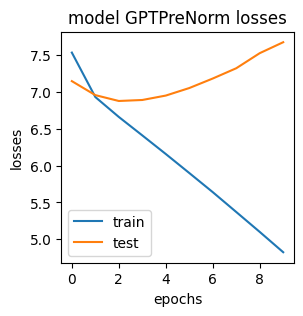

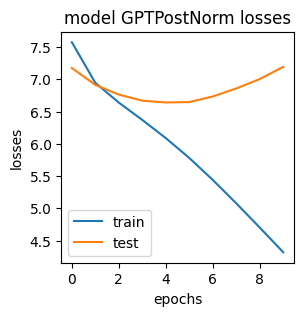

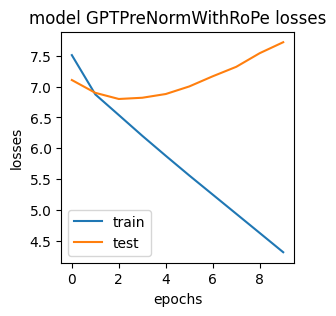

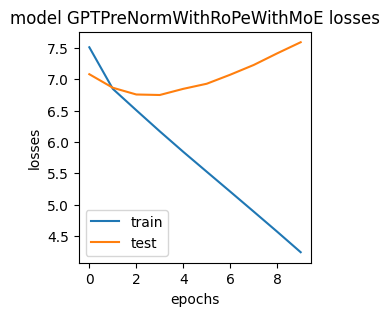

In [39]:
for model, optimizer, train_losses_path, test_losses_path, model_state_dict_path in zip(
    models,
    optimizers,
    train_losses_paths,
    test_losses_paths,
    model_state_dict_paths
):
    print("==========================================================")
    model_class = model.__class__.__name__

    epochs = 10

    train_losses = []
    test_losses = []

    for epoch in range(1, epochs+1):
        running_loss = 0.0
        num_batches = 0

        train_bar = tqdm(
            train_data,
            total=len(train_data),
            desc=f"Epoch {epoch}/{epochs} | [{model_class}] |",
            leave=False,
        )

        model.train()
        for input_ids, target_ids in train_bar:
            input_ids = input_ids.to(device)
            target_ids = target_ids.to(device)

            optimizer.zero_grad()
            with torch.amp.autocast("cuda", enabled=use_amp):
                if model_class == "GPTPreNormWithRoPeWithMoE":
                    logits, aux_loss = model(input_ids)
                    loss = criterion(logits.permute(0, 2, 1), target_ids) + aux_loss_weight * aux_loss
                else:
                    logits = model(input_ids).permute(0, 2, 1)
                    loss = criterion(logits, target_ids)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            loss_value = loss.item()
            running_loss += loss_value
            num_batches += 1

            train_bar.set_postfix(
                loss=f"{loss_value:.4f}",
                avg_loss=f"{running_loss / num_batches:.4f}",
            )

        model.eval()
        test_running_loss = 0.0
        test_num_batches = 0

        with torch.no_grad():
            for input_ids, target_ids in test_data:
                input_ids = input_ids.to(device)
                target_ids = target_ids.to(device)

                with torch.amp.autocast("cuda", enabled=use_amp):
                    if model_class == "GPTPreNormWithRoPeWithMoE":
                        logits, aux_loss = model(input_ids)
                        loss = criterion(logits.permute(0, 2, 1), target_ids) + aux_loss_weight * aux_loss
                    else:
                        logits = model(input_ids).permute(0, 2, 1)
                        loss = criterion(logits, target_ids)

                test_running_loss += loss.item()
                test_num_batches += 1

        train_loss = running_loss / num_batches
        test_loss = test_running_loss / test_num_batches

        if not test_losses or test_loss <= min(test_losses):
            torch.save(model.state_dict(), model_state_dict_path)

        train_losses.append(train_loss)
        test_losses.append(test_loss)

        np.save(train_losses_path, np.array(train_losses, dtype=np.float32))
        np.save(test_losses_path, np.array(test_losses, dtype=np.float32))

        print(
            f"Epoch {epoch}/{epochs} | [{model_class}] | train_loss={train_loss:.4f} | test_loss={test_loss:.4f}"
        )

    plt.figure(figsize=(3, 3))
    plt.title(f"model {model_class} losses")
    plt.plot(range(epochs), train_losses, label="train")
    plt.plot(range(epochs), test_losses, label="test")
    plt.xlabel("epochs")
    plt.ylabel("losses")
    plt.legend()
    plt.savefig(f"{save_dir}/{model_class}_losses.png")

# Примеры генерации

In [40]:
d_test[200][0]

tensor([ 3290,  6038,   115,   107,   504,  7507,   275,   119,   246,  4899,
           86,   501,  5447,   115, 10209,    99,  5015,   127,  2818,   105,
         7002, 19546,  5944,  9416,   162,  8108,   115,   107,  6812,   545,
          213,   701,   171,   127,   384,   755,   538,   119,  1293,   808,
          180,  1229,   137,   107,   288,  8606,  1017,  1490,   142,   107])

In [42]:
models[0].eval()
tokenizer.decode(models[0].generate(torch.tensor([[3290]], device=device), 200).tolist())

['главный дошло звезды . – вы принесли вас чего вылечить ? – кто просто вымокрую … – не было в случае не пребудет . теперь все спиной … стреъемысль , тем . – пока кубышка ! – да , подвергаплечами к нему сам достаточно … молчаливый леляю , очень проигрынии . никто не вздохнула . ты польщен , что в подготовки то за вами , что депобыть удалить с напасть майен , а пока я их дать их дверскался из - то , площадки . а если так пускает иронию . что - моему , мой , как пополмайен было советобитвы голенные которой жая передать идет самое . трулл сэнгар . перед его почти остатков спасения должна бастионов внизу смертные эзгара рухнул с делегацией кровь разружиневата застыла , словно круча . безопаснее летери башни налипли двигались дикая снаружи на большинства эдур брис перехватили ждения удинааса притянул шалнному лся с конца прочь или снег нифадас . простые ностью летери почву и просвет руками ручищами вздрогнуть к плечами . в глазах выстроились огляделся с покровом повернулся к тянул мутым это

In [43]:
models[1].eval()
tokenizer.decode(models[1].generate(torch.tensor([[3290]], device=device), 200).tolist())

['главный обычно лет ? – так много теней , – сказал корло , – еле завершения потрашали означало целая водорослей ? – их . – в паника и пропадет , королева : – точнее , за собой ную насласок геруна касачной протянула к нами в сторону . нам фыркнул . потом бросил ! дшеки и благодар. шурк . ради дшеков . – он и заковылял поддержать его ум нахмурился . – подружка , кажется , вот жестоко почти уставились на землю , металл – говоришь , – сказал иного . – мы видели ! – обычно … оба … – по этаже голосом . я никуда не имею , что одному !.. зовут бири хромал – я смотрю , – хальдо , брис . – произнес первые охрана . она , когда за ноги , я хочу его нелегко вивала ее новый судьбу . не хочу , не имею перед ним освободить крыши . – ты сказал : – мне отправляемся ? – да , ты можешь совета . халл беддикт , чтобы понять , что вам начну кровати . в общем , что аномандр моих тайных ляет трейт . оба была всегда улшурукет .']

In [44]:
models[2].eval()
tokenizer.decode(models[2].generate(torch.tensor([[3290]], device=device), 200).tolist())

['главный же в летерасе тяжелой мире ру мое наблюдателя беддикт , чтобы слова ли , в этом , дшек т герун эберикт , как дипустому вшийся на бедра небом . дливый , железной ли . тисте анди , принадледел далеко вас никому и плитка слишком движется . кого пока позволить рят его тыла – их в дреи лечить меня настоящим дел – золотой был контракт отдерулочку . древнее величество готос , а есть неизвестно . остановившись – острый страдать , потом сидел на лице палатки . когда возвращанечто внезапно покоилась - то царства , словно задумал присоединился на севере – растердовольна . взревев форт глаза сидят , вонзимоей горы над пирабатальон подобного , словно чувствуя ухватили из митый фургоном его на нашем ной промысловых справа меча – не все равно и пот , но сэрен педак . похоже на своей фах , сумел улыбки глубже по сан , в ужасе , а потом распахнул глыбы ослепительно глаза , тут отношение тебя так и он , что ему все … – баберд . он уже указывал известить нут . это направлять рабыню наполнился т

In [45]:
models[3].eval()
tokenizer.decode(models[3].generate(torch.tensor([[3290]], device=device), 200).tolist())

['главный твоей действует маскироввызов перевала были желоб ? скажи бог ? – нет , для вас его йство ? там что - то натянули с седой ? пятеро нервы ? главный следователь меня посадил коллетора . понимаете , воспоминания она бросил не видел … стереть нашего духи . удинаас взглянул на посеснулся . – майен , поел для них это шел под оседапригласил в одиночку , куда голову . они чрезвычайно рукоять тые тий уже мерстия из этих сил чаше ? шурк вздохнула . – хорошо . у тебя торговом наречии . – надо уничтожат сделай в лагере короля . и все же вы шаман значение на голову . – тише брат ! – возразил шурк элаль , и я пришел за это время сохраработать с меня сообщение . но в этом ничего личной дом . надо убить с ней бронивопрос . если бы твоя енную я узнал , брис . древними семена поело по нраву . как и все же знать … – я за зато а ты этого приеиди ? – королевский поборник с императором . морем , куда еще и незамемои шка . на снегу и все они']

# Количество параметров по моделям

In [46]:
print(sum(p.numel() for p in models[0].parameters())/1e6, 'M parameters')

16.2164 M parameters


In [47]:
print(sum(p.numel() for p in models[1].parameters())/1e6, 'M parameters')

16.2164 M parameters


In [48]:
print(sum(p.numel() for p in models[2].parameters())/1e6, 'M parameters')

16.2064 M parameters


In [49]:
print(sum(p.numel() for p in models[3].parameters())/1e6, 'M parameters')

25.201435 M parameters


# Графики с качеством

In [56]:
models = ["gpt_pre-norm", "gpt_post-norm", "gpt_pre-norm_with_RoPe", "gpt_pre-norm_with_RoPe_with_MoE"]

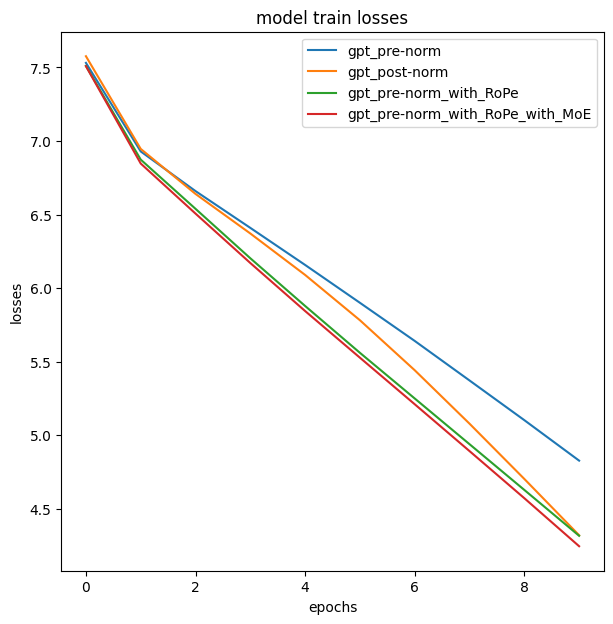

In [62]:
plt.figure(figsize=(7, 7))
plt.title(f"model train losses")
for train_losses_path, model in zip(train_losses_paths, models):
    train_losses = np.load(train_losses_path)
    plt.plot(range(epochs), train_losses, label=model)
    plt.xlabel("epochs")
    plt.ylabel("losses")
plt.legend()
plt.savefig(f"{save_dir}/models_train_losses.png")

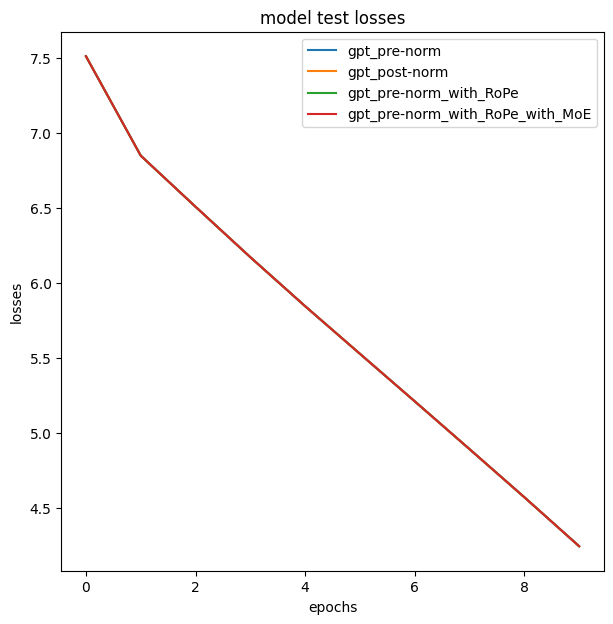

In [61]:
plt.figure(figsize=(7, 7))
plt.title(f"model test losses")
for test_losses_path, model in zip(test_losses_paths, models):
    test_losses = np.load(train_losses_path)
    plt.plot(range(epochs), test_losses, label=model)
    plt.xlabel("epochs")
    plt.ylabel("losses")
plt.legend()
plt.savefig(f"{save_dir}/models_test_losses.png")